In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

# Task 1: Data Preparation

In this task:

- load images from the Train and Test folders
- convert images to grayscale
- resize images to 28 x 28
- normalize pixel values to the range [0, 1]
- create labels from folder names
- reshape images for Keras
- convert labels to one-hot encoding

In [ ]:
# dataset path in Google Drive
dataset_path = "/content/drive/MyDrive/Week-4/DevanagariHandwrittenDigitDataset"

# train and test folders
train_dir = f"{dataset_path}/Train"
test_dir = f"{dataset_path}/Test"

# image size
img_height, img_width = 28, 28

## Check dataset path

This step checks if the Train and Test folders are found.

In [ ]:
print("Train path exists:", os.path.exists(train_dir))
print("Test path exists:", os.path.exists(test_dir))

## Load images from folders

We create one function to:

- read each class folder
- open each image
- convert it to grayscale
- resize it to 28 x 28
- normalize pixel values
- save the image and label

In [ ]:
def load_images_from_folder(folder):
    images = []
    labels = []

    # sort class folders like digit_0, digit_1, ...
    class_names = sorted(os.listdir(folder))

    # create label map
    class_map = {class_name: i for i, class_name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # open image and convert to grayscale
            img = Image.open(img_path).convert("L")

            # resize image to 28 x 28
            img = img.resize((img_width, img_height))

            # convert image to numpy array and normalize
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [48]:
# reload original images and integer labels
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# reshape images for Keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# one-hot encode labels only once
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# check shapes
print("Training set shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing set shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training set shape: (17000, 28, 28, 1)
Training labels shape: (17000, 10)
Testing set shape: (3000, 28, 28, 1)
Testing labels shape: (3000, 10)


## Show sample images

This step helps us check that the images and labels were loaded correctly.

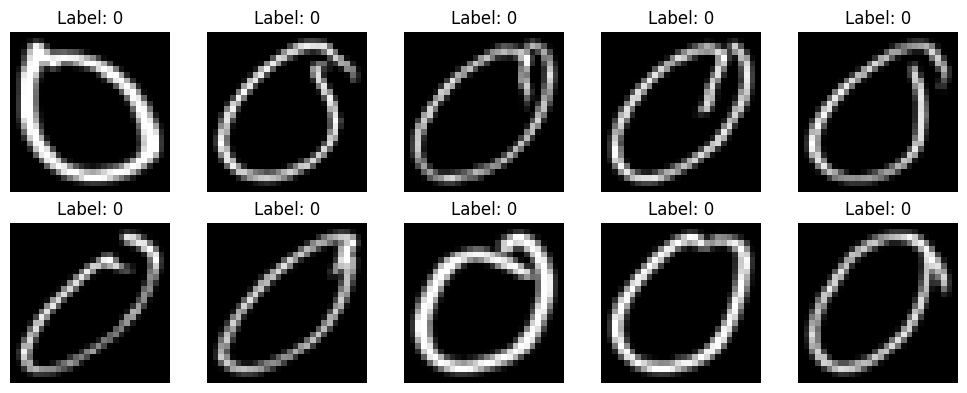

In [49]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2: Build the FCN Model

In this task, we will build a simple Fully Connected Network.

Model structure:

- input layer
- flatten layer
- hidden layer with 64 neurons
- hidden layer with 128 neurons
- hidden layer with 256 neurons
- output layer with 10 neurons

## Show model summary

This step helps us check the model structure and number of parameters.

In [51]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,464 (1.08 MB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 188,310 (735.59 KB)

# Task 3: Compile the Model

In this task, we will compile the model.

We use:
- Adam optimizer
- categorical crossentropy loss
- accuracy as the evaluation metric

In [52]:
# rebuild the model
num_classes = 10
input_shape = (28, 28, 1)

model = Sequential([
    Input(shape=input_shape),
    Flatten(),
    Dense(64, activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    Dense(256, activation="sigmoid"),
    Dense(num_classes, activation="softmax")
])

# compile again
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Task 4: Train the Model

In this task, we will train the FCN model.

We use:
- batch size = 128
- epochs = 20
- validation split = 0.2

We also use callbacks:
- ModelCheckpoint to save the model
- EarlyStopping to stop early if validation loss does not improve

In [54]:
# shuffle training data
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train = y_train[indices]

In [55]:
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7226 - loss: 0.8865 - val_accuracy: 0.8550 - val_loss: 0.5240
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8883 - loss: 0.4021 - val_accuracy: 0.9074 - val_loss: 0.3124
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9237 - loss: 0.2608 - val_accuracy: 0.9353 - val_loss: 0.2311
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9457 - loss: 0.1946 - val_accuracy: 0.9476 - val_loss: 0.1908
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9563 - loss: 0.1529 - val_accuracy: 0.9547 - val_loss: 0.1641
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9649 - loss: 0.1243 - val_accuracy: 0.9579 - val_loss: 0.1456
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9713 - loss: 0.1010 - val_accuracy: 0.9635 - val_loss: 0.1314
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9783 - loss: 0.0837 - val_accuracy

# Task 5: Evaluate the Model

In this task, we evaluate the trained model on the test set.

This helps us measure how well the model performs on unseen data.

In [56]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9783 - loss: 0.0814
Test Loss: 0.08136773109436035
Test Accuracy: 0.9783333539962769


# Task 6: Save and Load the Model

In this task, we save the trained model and load it again.

This helps us reuse the model later without training it again.

In [57]:
# save the model
model.save("devnagari_fcn_model.h5")

In [58]:
# load the saved model
loaded_model = load_model("devnagari_fcn_model.h5")

In [59]:
# evaluate the loaded model
loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test, y_test, verbose=1)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9783 - loss: 0.0814
Loaded Model Test Loss: 0.08136773109436035
Loaded Model Test Accuracy: 0.9783333539962769


# Task 7: Predictions

In this task, we use the loaded model to make predictions on the test images.

The model gives probabilities for each class.
We convert those probabilities into class labels using `argmax`.

In [60]:
# predict on test data
predictions = loaded_model.predict(x_test, verbose=1)

# convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [61]:
# check the first prediction
print("Predicted label for first image:", predicted_labels[0])
print("True label for first image:", true_labels[0])

Predicted label for first image: 0
True label for first image: 0


## Show random prediction examples

This step shows predictions on random test images from different classes.

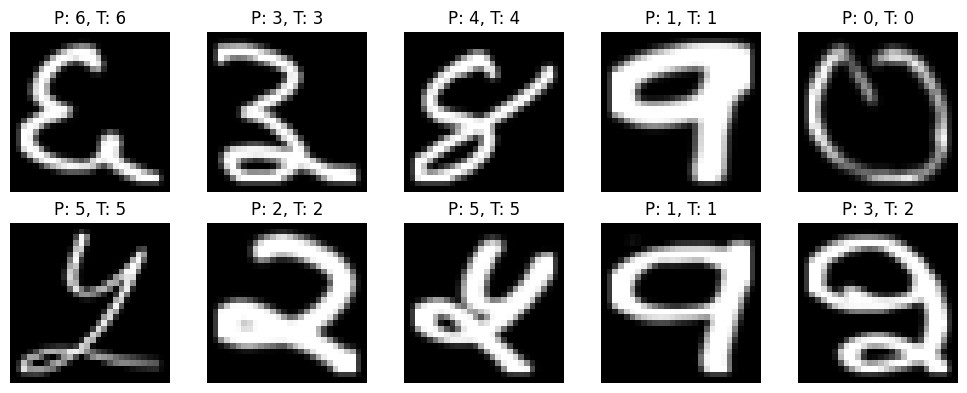

In [64]:
plt.figure(figsize=(10, 4))

random_indices = np.random.choice(len(x_test), 10, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"P: {predicted_labels[idx]}, T: {true_labels[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 8: Visualization of Training Performance

In this task, we plot training and validation accuracy and loss.

These graphs help us understand how the model learned during training.

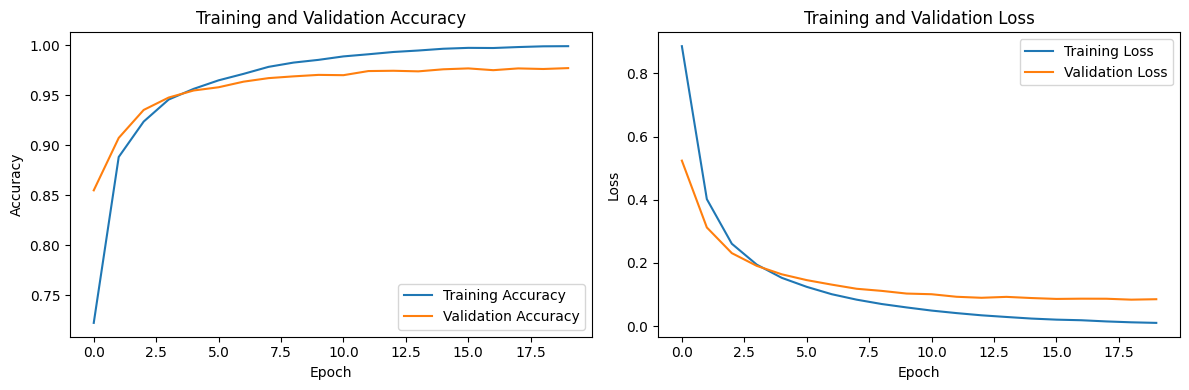

In [65]:
plt.figure(figsize=(12, 4))

# accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Result

The graphs show the training and validation accuracy and loss over epochs.

These plots help us check whether the model learned well and whether it generalizes well to unseen data.